In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
cash_rate=pd.read_csv('cash_rate.csv')
prices = pd.read_csv('prices.csv')
signals = pd.read_csv('signals.csv')
volumes = pd.read_csv('volumes.csv')

prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2851 entries, 0 to 2850
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           2851 non-null   object 
 1   INSTRUMENT_1   2851 non-null   float64
 2   INSTRUMENT_2   2851 non-null   float64
 3   INSTRUMENT_3   2851 non-null   float64
 4   INSTRUMENT_4   2851 non-null   float64
 5   INSTRUMENT_5   2851 non-null   float64
 6   INSTRUMENT_6   2851 non-null   float64
 7   INSTRUMENT_7   2851 non-null   float64
 8   INSTRUMENT_8   2851 non-null   float64
 9   INSTRUMENT_9   2851 non-null   float64
 10  INSTRUMENT_10  2851 non-null   float64
dtypes: float64(10), object(1)
memory usage: 245.1+ KB


In [5]:
cash_rate.tail()

,date,1mo,1.5month,2mo,3mo,4mo,6mo,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
8752,2024-12-24,4.44,NaN,4.44,4.40,4.38,4.30,4.24,4.29,4.36,4.43,4.52,4.59,4.84,4.76
8753,2024-12-26,4.45,NaN,4.45,4.35,4.37,4.31,4.23,4.30,4.35,4.42,4.49,4.58,4.83,4.76
8754,2024-12-27,4.44,NaN,4.43,4.31,4.35,4.29,4.20,4.31,4.36,4.45,4.53,4.62,4.89,4.82
8755,2024-12-30,4.43,NaN,4.42,4.37,4.33,4.25,4.17,4.24,4.29,4.37,4.46,4.55,4.84,4.77
8756,2024-12-31,4.40,NaN,4.39,4.37,4.32,4.24,4.16,4.25,4.27,4.38,4.48,4.58,4.86,4.78


In [4]:
prices.head()

,date,INSTRUMENT_1,INSTRUMENT_2,INSTRUMENT_3,INSTRUMENT_4,INSTRUMENT_5,INSTRUMENT_6,INSTRUMENT_7,INSTRUMENT_8,INSTRUMENT_9,INSTRUMENT_10
0,2017-01-03,196.68,112.72,49.97,29.81,96.29,96.91,110.47,91.52,4285.08,302.00
1,2017-01-04,197.85,113.32,50.53,30.04,96.66,97.02,110.86,92.63,4285.41,301.90
2,2017-01-05,197.71,113.93,50.96,30.36,98.21,97.69,112.59,93.60,4286.03,301.83
3,2017-01-06,198.39,114.93,50.79,30.24,97.29,97.22,111.76,93.44,4286.33,301.89
4,2017-01-09,197.78,115.32,50.71,30.21,98.10,97.61,112.69,90.47,4287.06,301.92


In [27]:
signals.head(32)

,date,INSTRUMENT_1_trend4,INSTRUMENT_1_trend8,INSTRUMENT_1_trend16,INSTRUMENT_1_trend32,INSTRUMENT_2_trend4,INSTRUMENT_2_trend8,INSTRUMENT_2_trend16,INSTRUMENT_2_trend32,INSTRUMENT_3_trend4,...,INSTRUMENT_8_trend16,INSTRUMENT_8_trend32,INSTRUMENT_9_trend4,INSTRUMENT_9_trend8,INSTRUMENT_9_trend16,INSTRUMENT_9_trend32,INSTRUMENT_10_trend4,INSTRUMENT_10_trend8,INSTRUMENT_10_trend16,INSTRUMENT_10_trend32
0,2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
volumes.tail()
prices.columns

Index(['date', 'INSTRUMENT_1', 'INSTRUMENT_2', 'INSTRUMENT_3', 'INSTRUMENT_4',
       'INSTRUMENT_5', 'INSTRUMENT_6', 'INSTRUMENT_7', 'INSTRUMENT_8',
       'INSTRUMENT_9', 'INSTRUMENT_10'],
      dtype='object')

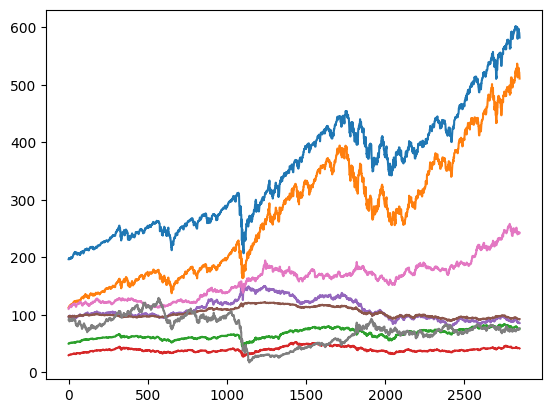

In [21]:
for instrument in prices.columns[1:]:
    if instrument != "INSTRUMENT_9" and instrument != "INSTRUMENT_10":
        instrument_price=prices[instrument]
        plt.plot(instrument_price)
    else:
        pass


plt.show()

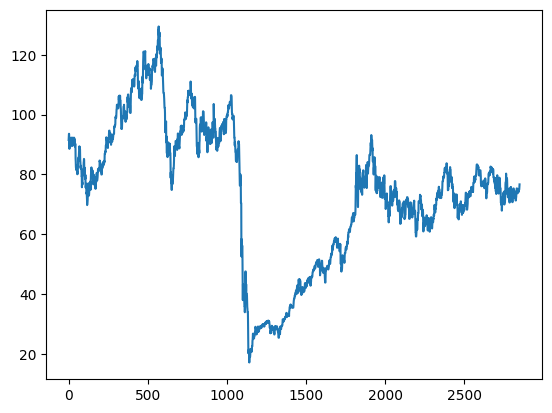

In [23]:
plt.plot(prices['INSTRUMENT_8'])

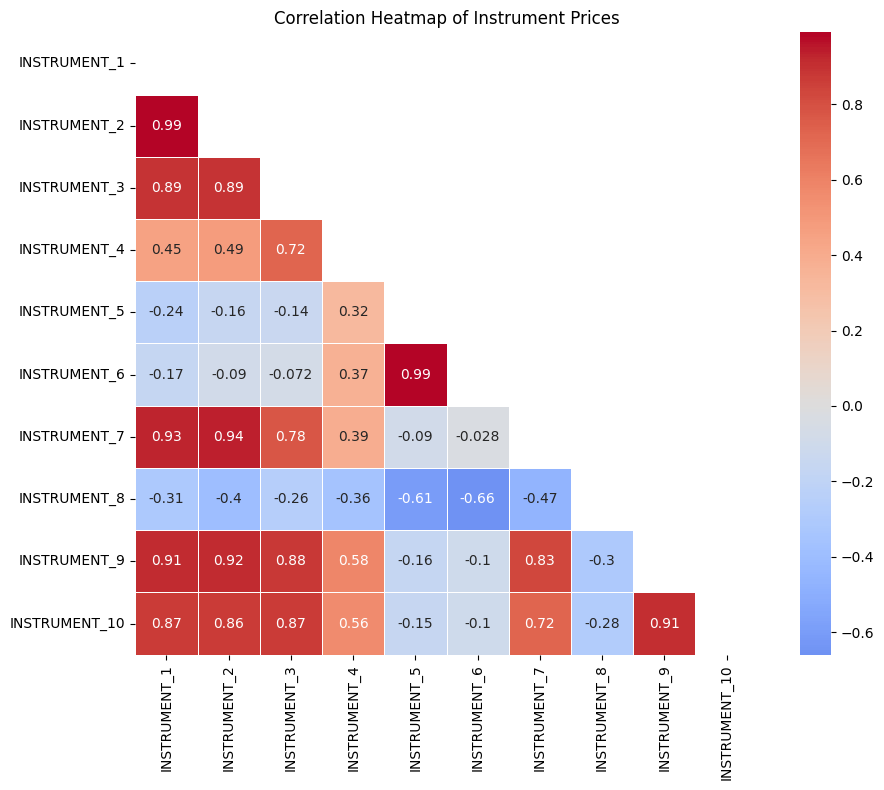

In [22]:
corr = prices.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center = 0, square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Instrument Prices')
plt.tight_layout()
plt.show()